#1 - Data Acquisition

In [3]:
!pip install tensorflow scikit-learn seaborn matplotlib numpy pandas joblib -q

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn
import joblib
import os
import random
import urllib.request
import zipfile

In [7]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [8]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ZIP_PATH = "har.zip"
EXTRACT_PATH = "."

urllib.request.urlretrieve(URL, ZIP_PATH)
print("Download complete")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("Extraction complete")

Download complete
Extraction complete


In [11]:
DATASET_PATH = "UCI HAR Dataset"

# Extract the inner zip file if it exists
INNER_ZIP_PATH = "UCI HAR Dataset.zip"
if os.path.exists(INNER_ZIP_PATH):
    with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as z:
        z.extractall(".") # Extract to current directory
    print(f"Inner zip '{INNER_ZIP_PATH}' extracted.")

with open(f"{DATASET_PATH}/activity_labels.txt") as f:
    activity_labels = f.read()
print(activity_labels)

Inner zip 'UCI HAR Dataset.zip' extracted.
1 WALKING
2 WALKING_UPSTAIRS
3 WALKING_DOWNSTAIRS
4 SITTING
5 STANDING
6 LAYING



#2 - Load Data

In [12]:
ACTIVITY_NAMES = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

In [15]:
def load_signals(split):
    signals_path = f"{DATASET_PATH}/{split}/Inertial Signals"
    signal_files = sorted(os.listdir(signals_path))
    signals = []

    for f in signal_files:
        data = pd.read_csv(
            f"{signals_path}/{f}",
            delim_whitespace=True, header=None
        )

        signals.append(data.values)

    return np.stack(signals, axis=2)

In [16]:
def load_labels(split):
    path = f"{DATASET_PATH}/{split}/y_{split}.txt"
    labels = pd.read_csv(path, header=None).values.flatten()

    return labels - 1

In [17]:
X_train = load_signals("train")
X_test  = load_signals("test")
y_train = load_labels("train")
y_test  = load_labels("test")

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

/tmp/ipykernel_4296/3612882506.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/tmp/ipykernel_4296/3612882506.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/tmp/ipykernel_4296/3612882506.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/tmp/ipykernel_4296/3612882506.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/tmp/ipykernel_4296/3612882506.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_

X_train shape: (7352, 128, 9)
X_test shape:  (2947, 128, 9)
y_train shape: (7352,)
y_test shape:  (2947,)


In [18]:
assert X_train.shape == (7352, 128, 9), f"Unexpected shape: {X_train.shape}"
assert X_test.shape  == (2947, 128, 9), f"Unexpected shape: {X_test.shape}"
assert y_train.shape == (7352,),        f"Unexpected shape: {y_train.shape}"
assert y_test.shape  == (2947,),        f"Unexpected shape: {y_test.shape}"

assert y_train.min() == 0 and y_train.max() == 5, "Labels not in range 0–5"
assert y_test.min()  == 0 and y_test.max()  == 5, "Labels not in range 0–5"

print("All shape and label checks passed")

All shape and label checks passed


In [19]:
def load_subjects(split):
    path = f"{DATASET_PATH}/{split}/subject_{split}.txt"

    return pd.read_csv(path, header=None).values.flatten()


In [20]:
subjects_train = load_subjects("train")
subjects_test  = load_subjects("test")

print("Unique subjects in train:", sorted(np.unique(subjects_train)))
print("Unique subjects in test: ", sorted(np.unique(subjects_test)))
print("Total subjects:", len(np.unique(np.concatenate([subjects_train, subjects_test]))))

Unique subjects in train: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Unique subjects in test:  [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Total subjects: 30


#3 - Class distribution

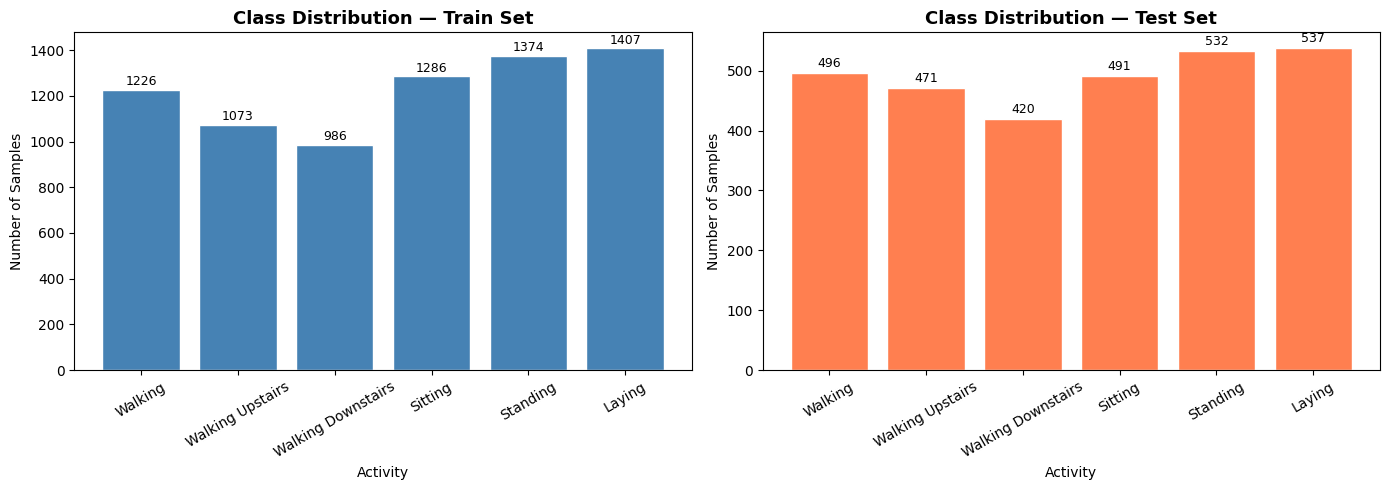


Train class counts:
  Walking                  : 1226
  Walking Upstairs         : 1073
  Walking Downstairs       : 986
  Sitting                  : 1286
  Standing                 : 1374
  Laying                   : 1407


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution
train_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(ACTIVITY_NAMES, train_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — Train Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# Test distribution
test_counts = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(ACTIVITY_NAMES, test_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Class Distribution — Test Set', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Activity')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTrain class counts:")
for i, name in enumerate(ACTIVITY_NAMES):
    print(f"  {name:25s}: {train_counts[i]}")

What to observe: Are the classes roughly balanced? Any single class with significantly more or fewer samples than others?

---> Walking Downstairs in training is lowest and Laying is highest

#4 - Raw signal visualization per class

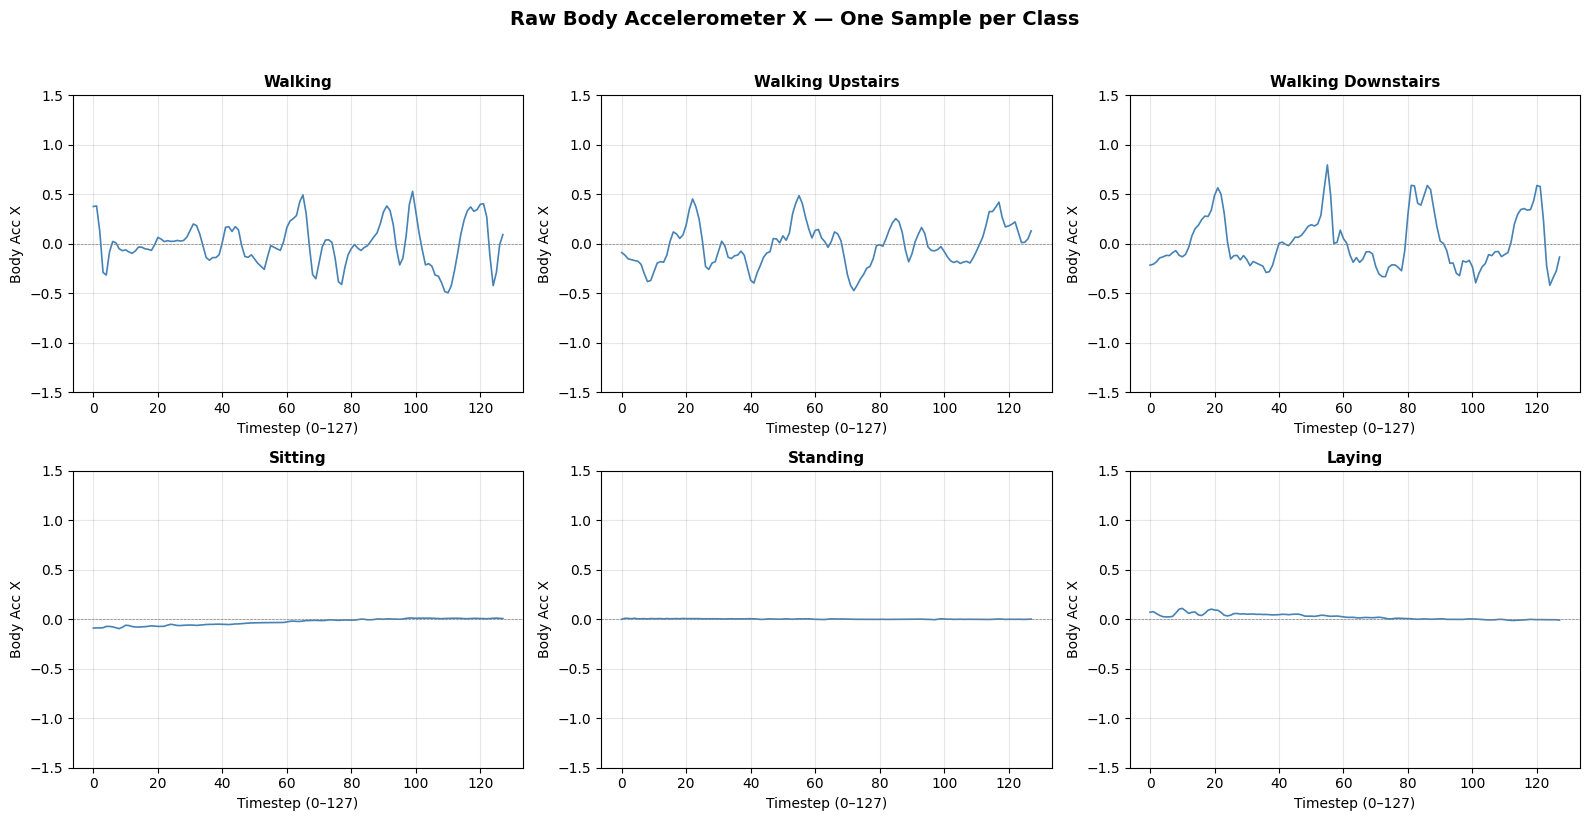

In [22]:
CHANNEL_NAMES = [
    'Body Acc X', 'Body Acc Y', 'Body Acc Z',
    'Body Gyro X', 'Body Gyro Y', 'Body Gyro Z',
    'Total Acc X', 'Total Acc Y', 'Total Acc Z'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for class_id in range(6):
    # Pick the first sample of this class
    idx = np.where(y_train == class_id)[0][0]

    # Plot channel 0 (Body Accelerometer X)
    axes[class_id].plot(X_train[idx, :, 0], color='steelblue', linewidth=1.2)
    axes[class_id].set_title(ACTIVITY_NAMES[class_id], fontsize=11, fontweight='bold')
    axes[class_id].set_xlabel('Timestep (0–127)')
    axes[class_id].set_ylabel('Body Acc X')
    axes[class_id].set_ylim(-1.5, 1.5)
    axes[class_id].axhline(0, color='gray', linewidth=0.5, linestyle='--')
    axes[class_id].grid(True, alpha=0.3)

plt.suptitle('Raw Body Accelerometer X — One Sample per Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('signal_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

Observations:

*  Walking, Walking Upstairs, Walking Downstairs looks rhythmic and periodic

*  Sitting and Laying looks nearly flat with tiny fluctuations

* Standing is be the flattest of all



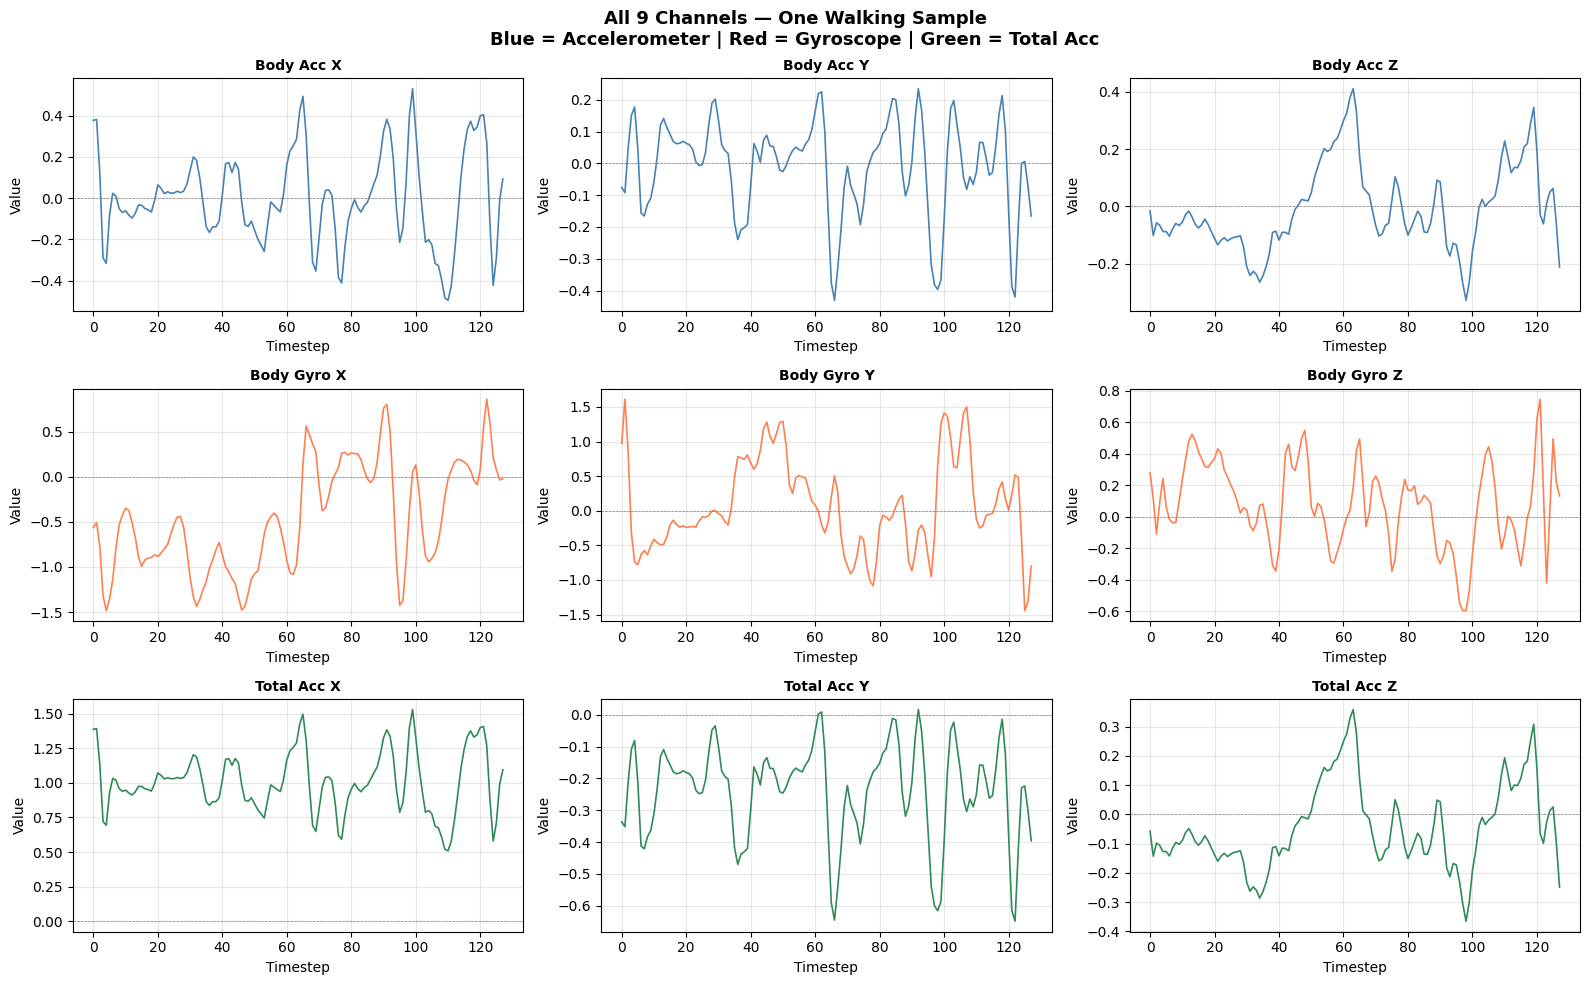

In [23]:
# Pick one walking sample
walk_idx = np.where(y_train == 0)[0][0]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'steelblue', 'steelblue',
          'coral', 'coral', 'coral',
          'seagreen', 'seagreen', 'seagreen']

for ch in range(9):
    axes[ch].plot(X_train[walk_idx, :, ch],
                  color=colors[ch], linewidth=1.2)
    axes[ch].set_title(CHANNEL_NAMES[ch], fontsize=10, fontweight='bold')
    axes[ch].set_xlabel('Timestep')
    axes[ch].set_ylabel('Value')
    axes[ch].grid(True, alpha=0.3)
    axes[ch].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('All 9 Channels — One Walking Sample\n'
             'Blue = Accelerometer | Red = Gyroscope | Green = Total Acc',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_channels_walking.png', dpi=150, bbox_inches='tight')
plt.show()

Observations:


*   The three accelerometer body channels (blue) and three gyroscope channels (red) look different from each other
*   Total accelerometer (green) and body accelerometer (blue) look similar — they are related signals
*   Some channels carry more information than others



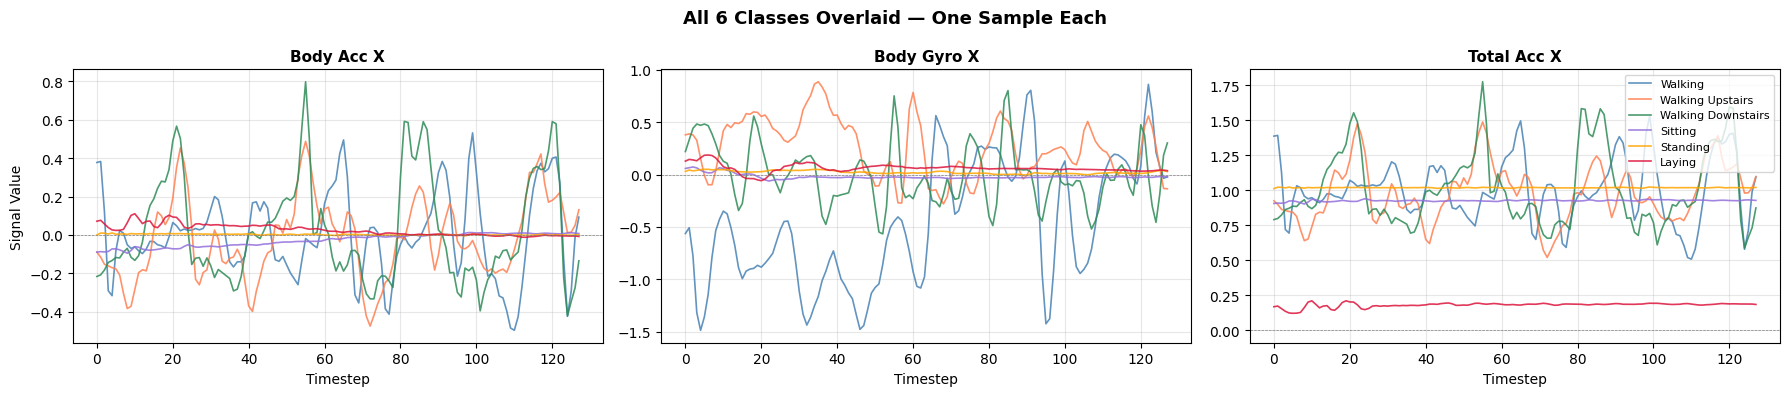

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

class_colors = ['steelblue', 'coral', 'seagreen',
                'mediumpurple', 'orange', 'crimson']

channels_to_plot = [0, 3, 6]  # Body Acc X, Body Gyro X, Total Acc X
channel_labels   = ['Body Acc X', 'Body Gyro X', 'Total Acc X']

for ax_idx, (ch, ch_name) in enumerate(zip(channels_to_plot, channel_labels)):
    for class_id in range(6):
        idx = np.where(y_train == class_id)[0][0]
        axes[ax_idx].plot(
            X_train[idx, :, ch],
            label=ACTIVITY_NAMES[class_id],
            color=class_colors[class_id],
            linewidth=1.2, alpha=0.85
        )
    axes[ax_idx].set_title(ch_name, fontsize=11, fontweight='bold')
    axes[ax_idx].set_xlabel('Timestep')
    axes[ax_idx].grid(True, alpha=0.3)
    axes[ax_idx].axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[0].set_ylabel('Signal Value')
axes[2].legend(loc='upper right', fontsize=8)

plt.suptitle('All 6 Classes Overlaid — One Sample Each',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

Observations:


*   Static activities (Sitting, Standing, Laying) cluster near zero. Dynamic activities (Walking variants) oscillate.



# 5 - Signal statistics per channel

In [25]:
print("Per-channel statistics across ALL training samples")
print("=" * 65)
print(f"{'Channel':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 65)

stats_rows = []
for ch in range(9):
    channel_data = X_train[:, :, ch].flatten()
    mean = channel_data.mean()
    std  = channel_data.std()
    mn   = channel_data.min()
    mx   = channel_data.max()
    print(f"{CHANNEL_NAMES[ch]:<20} {mean:>8.4f} {std:>8.4f} {mn:>8.4f} {mx:>8.4f}")
    stats_rows.append({
        'Channel': CHANNEL_NAMES[ch],
        'Mean': round(mean, 4),
        'Std': round(std, 4),
        'Min': round(mn, 4),
        'Max': round(mx, 4)
    })

stats_df = pd.DataFrame(stats_rows)

Per-channel statistics across ALL training samples
Channel                  Mean      Std      Min      Max
-----------------------------------------------------------------
Body Acc X            -0.0006   0.1948  -1.2322   1.2999
Body Acc Y            -0.0003   0.1224  -1.3453   0.9760
Body Acc Z            -0.0003   0.1069  -1.3647   1.0669
Body Gyro X            0.0005   0.4068  -4.7337   4.1555
Body Gyro Y           -0.0008   0.3819  -5.9743   5.7461
Body Gyro Z            0.0001   0.2557  -2.7630   2.3660
Total Acc X            0.8047   0.4141  -0.4666   2.1976
Total Acc Y            0.0288   0.3910  -1.5821   1.2173
Total Acc Z            0.0865   0.3578  -1.6396   1.2814


observation: The means are not all zero and the standard deviations are not all one. This confirms normalization is necessary before training.

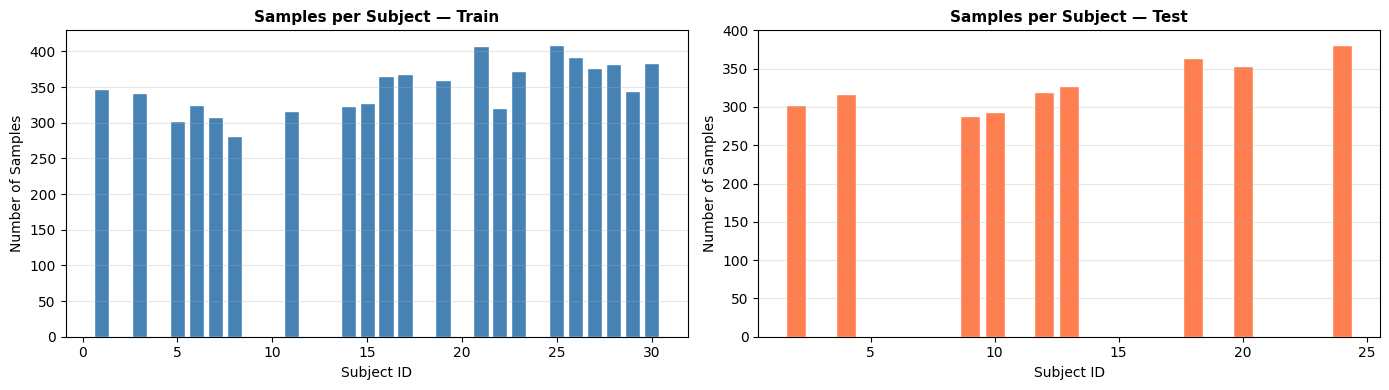

Subjects in train : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Subjects in test  : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Overlap           : None — clean split confirmed


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Train subjects
train_subject_counts = pd.Series(subjects_train).value_counts().sort_index()
axes[0].bar(train_subject_counts.index,
            train_subject_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Samples per Subject — Train', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3, axis='y')

# Test subjects
test_subject_counts = pd.Series(subjects_test).value_counts().sort_index()
axes[1].bar(test_subject_counts.index,
            test_subject_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Samples per Subject — Test', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Confirm no overlap
train_subjects = set(np.unique(subjects_train))
test_subjects  = set(np.unique(subjects_test))
overlap        = train_subjects.intersection(test_subjects)

print(f"Subjects in train : {sorted(train_subjects)}")
print(f"Subjects in test  : {sorted(test_subjects)}")
print(f"Overlap           : {overlap if overlap else 'None — clean split confirmed'}")

In [27]:
for i, name in enumerate(ACTIVITY_NAMES):
    print(f"{name:25s}: {train_counts[i]}")

Walking                  : 1226
Walking Upstairs         : 1073
Walking Downstairs       : 986
Sitting                  : 1286
Standing                 : 1374
Laying                   : 1407


#6 -  EDA Observations

### 1. Class Balance
Training set: 7352 samples across 6 classes.
Largest class  — Laying           : 1407 samples
Smallest class — Walking Downstairs: 986 samples
Gap: 421 samples (5.7% of total training data)
Classes are roughly balanced — weighted loss is not required.

### 2. Signal Patterns
Walking, Walking Upstairs, and Walking Downstairs show clear
rhythmic periodic oscillations across 128 timesteps.
Sitting and Laying appear nearly flat with tiny fluctuations.
Standing is the flattest of all six activities.

The three walking activities look visually similar to each other —
this is likely where the model will make the most confusion errors.

### 3. Channel Observations
Body Accelerometer (blue) and Gyroscope (red) channels carry
distinctly different information. Total Accelerometer (green)
closely resembles Body Accelerometer (blue) — related signals.
Static activities cluster near zero across all channels.
Dynamic activities oscillate clearly above and below zero.

### 4. Normalization
Raw channel means are not zero and standard deviations are
not one across all 9 channels. Channels are not on a common
scale. StandardScaler normalization is required before training.

### 5. Subject Split
21 subjects in train, 9 in test. Zero overlap confirmed.
Subject-independent evaluation — model tested on unseen people.

### Key Takeaway
The primary challenge in this dataset is distinguishing within
two groups: the three walking variants (visually similar signals)
and the three static activities (all near-flat but at different
baseline levels). A model that understands temporal patterns
should handle walking variants better than one that does not.